In [13]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [14]:
def load_probing_results(results_root="../logs/probing") -> pd.DataFrame:
    root = Path(results_root)
    result_paths = sorted(root.glob("**/result.csv"))

    if not result_paths:
        return pd.DataFrame(columns=["dataset", "model", "test_accuracy", "result_path"])

    frames = []
    for result_path in result_paths:
        run_df = pd.read_csv(result_path)
        if run_df.empty:
            continue

        run_df["result_path"] = str(result_path)

        # Fallback to path-derived metadata if columns are missing.
        if "dataset" not in run_df.columns and len(result_path.parts) >= 3:
            run_df["dataset"] = result_path.parts[-3]
        if "model" not in run_df.columns and len(result_path.parts) >= 2:
            run_df["model"] = result_path.parts[-2]

        frames.append(run_df)

    if not frames:
        return pd.DataFrame(columns=["dataset", "model", "test_accuracy", "result_path"])

    df = pd.concat(frames, ignore_index=True)
    df["test_accuracy"] = pd.to_numeric(df["test_accuracy"], errors="coerce")

    columns = ["dataset", "model", "test_accuracy", "result_path"]
    available_columns = [c for c in columns if c in df.columns]
    return df[available_columns].sort_values(["dataset", "model"], ignore_index=True)


df = load_probing_results("../logs/probing")
df


,dataset,model,test_accuracy,result_path
0,cifar10,openai_clip,0.9509,../logs/probing/cifar10/openai_clip/result.csv
1,cifar10,resnet50,0.9153,../logs/probing/cifar10/resnet50/result.csv
2,cifar100,openai_clip,0.7838,../logs/probing/cifar100/openai_clip/result.csv
3,cifar100,resnet50,0.7327,../logs/probing/cifar100/resnet50/result.csv
4,eurosat,openai_clip,0.9269,../logs/probing/eurosat/openai_clip/result.csv
5,eurosat,resnet50,0.9406,../logs/probing/eurosat/resnet50/result.csv
6,food101,openai_clip,0.9193,../logs/probing/food101/openai_clip/result.csv
7,food101,resnet50,0.5914,../logs/probing/food101/resnet50/result.csv
8,mnist,openai_clip,0.9677,../logs/probing/mnist/openai_clip/result.csv
9,mnist,resnet50,0.9576,../logs/probing/mnist/resnet50/result.csv


In [20]:
pivot = df.pivot_table(index="dataset", columns="model", values="test_accuracy", aggfunc="last")
pivot = pivot.reindex(columns=["openai_clip", "resnet50"])
pivot["delta_clip_minus_resnet50"] = pivot["openai_clip"] - pivot["resnet50"]
pivot["delta_percentage_points"] = pivot["delta_clip_minus_resnet50"] * 100
pivot["delta_relative_percent"] = pivot["delta_clip_minus_resnet50"] / pivot["resnet50"] * 100
pivot = pivot.reset_index()
pivot.sort_values(by=["delta_percentage_points"], inplace=True, ascending=False)
pivot

model,dataset,openai_clip,resnet50,delta_clip_minus_resnet50,delta_percentage_points,delta_relative_percent
3,food101,0.9193,0.5914,0.3279,32.79,55.444707
1,cifar100,0.7838,0.7327,0.0511,5.11,6.974205
0,cifar10,0.9509,0.9153,0.0356,3.56,3.889435
4,mnist,0.9677,0.9576,0.0101,1.01,1.054720
2,eurosat,0.9269,0.9406,-0.0137,-1.37,-1.456517


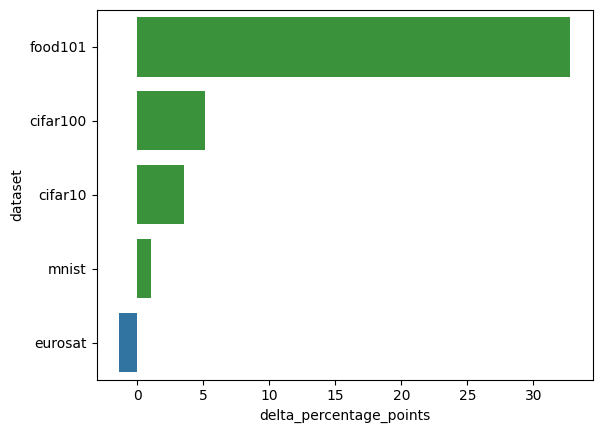

In [22]:
pivot["sign"] = pivot["delta_percentage_points"] > 0

sns.barplot(
    data=pivot,
    y="dataset",
    x="delta_percentage_points",
    hue="sign",
    dodge=False,
    palette={True: "#2ca02c", False: "#1f77b4"},
    legend=False,
)
plt.savefig("../figures/linear_probing.png")